
# Revisiting my 2021 Master's Thesis in Python
## Parte 1 — Data cleaning & Exploratory Data Analysis

**Tesi originale:** *Il machine learning per la previsione degli acquisti online. Il caso Google Store.*

Questo notebook ricostruisce in Python la parte di **data cleaning** e **analisi esplorativa** del progetto originale sviluppato in R nel 2021.

### Obiettivo di questa prima parte

Non si tratta di una traduzione riga-per-riga da R a Python. L'obiettivo è:

- preservare la logica dell'analisi originale;
- rendere espliciti i passaggi impliciti;
- correggere bug o passaggi fragili individuati durante la revisione;
- mantenere separato il **ricavo monetario** dalla target binaria **acquisto / non acquisto**;
- produrre grafici più leggibili e riproducibili;
- preparare una base affidabile per la successiva revisione dei modelli.

> **Nota:** i modelli di classificazione, le tecniche di bilanciamento e il confronto 2021 vs 2026 saranno affrontati nella Parte 2.



## 1. Contesto del dataset

Il dataset originale Google Store conteneva oltre 900 mila sessioni. Per la tesi era stato estratto un **campione casuale di 25.000 osservazioni** per esigenze computazionali.

La variabile `transactionRevenue` contiene il ricavo associato alla sessione. Nel lavoro originale veniva successivamente trasformata in una variabile dicotomica per la classificazione:

- `0`: nessun acquisto;
- `1`: acquisto.

In questa revisione manteniamo **entrambe** le informazioni:

- `transactionRevenue` / `revenue_usd` per l'EDA;
- `purchase` come target binaria per il machine learning.


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = Path("Data_Frame_Gstore_sample.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/Data_Frame_Gstore_sample.csv")

DATA_PATH


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ko_94bxb because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


PosixPath('Data_Frame_Gstore_sample.csv')


## 2. Caricamento del campione

Il CSV originale non è codificato in UTF-8. Viene quindi letto con codifica `cp1252`, coerente con il file utilizzato nella tesi.


In [2]:

raw = pd.read_csv(DATA_PATH, encoding="cp1252", low_memory=False)

print(f"Osservazioni: {raw.shape[0]:,}")
print(f"Variabili:    {raw.shape[1]}")
display(raw.head())


Osservazioni: 25,000
Variabili:    56


,Unnamed: 0,channelGrouping,date,fullVisitorId,sessionId,socialEngagementType,visitId,visitNumber,visitStartTime,browser,browserVersion,browserSize,operatingSystem,operatingSystemVersion,isMobile,mobileDeviceBranding,mobileDeviceModel,mobileInputSelector,mobileDeviceInfo,mobileDeviceMarketingName,flashVersion,language,screenColors,screenResolution,deviceCategory,continent,subContinent,country,region,metro,city,cityId,networkDomain,latitude,longitude,networkLocation,visits,hits,pageviews,bounces,newVisits,transactionRevenue,campaign,source,medium,keyword,isTrueDirect,referralPath,adContent,campaignCode,adwordsClickInfo.criteriaParameters,adwordsClickInfo.page,adwordsClickInfo.slot,adwordsClickInfo.gclId,adwordsClickInfo.adNetworkType,adwordsClickInfo.isVideoAd
0,67520,Social,20170228,6924322715895180517,6924322715895180517_1488310191,Not Socially Engaged,1488310191,1,1488310191,Chrome,not available in demo dataset,not available in demo dataset,Windows,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,desktop,Americas,Central America,Mexico,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,avantel.net.mx,not available in demo dataset,not available in demo dataset,not available in demo dataset,1,1,1.00,1.00,1.00,NaN,(not set),youtube.com,referral,NaN,NaN,/yt/about/ru/,NaN,NaN,not available in demo dataset,NaN,NaN,NaN,NaN,NaN
1,165686,Social,20161021,3087397509850951029,3087397509850951029_1477049492,Not Socially Engaged,1477049492,1,1477049492,Chrome,not available in demo dataset,not available in demo dataset,Windows,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,desktop,Europe,Northern Europe,Norway,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,nextgentel.com,not available in demo dataset,not available in demo dataset,not available in demo dataset,1,1,1.00,1.00,1.00,NaN,(not set),youtube.com,referral,NaN,NaN,/yt/about/no/,NaN,NaN,not available in demo dataset,NaN,NaN,NaN,NaN,NaN
2,106499,Organic Search,20170213,2547105470369992495,2547105470369992495_1487011296,Not Socially Engaged,1487011296,1,1487011296,Safari,not available in demo dataset,not available in demo dataset,Macintosh,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,desktop,Americas,South America,Brazil,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,virtua.com.br,not available in demo dataset,not available in demo dataset,not available in demo dataset,1,9,9.00,NaN,1.00,NaN,(not set),google,organic,(not provided),NaN,NaN,NaN,NaN,not available in demo dataset,NaN,NaN,NaN,NaN,NaN
3,790339,Direct,20170322,9982985779332389803,9982985779332389803_1490201370,Not Socially Engaged,1490201370,8,1490201370,Chrome,not available in demo dataset,not available in demo dataset,Chrome OS,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,desktop,Europe,Western Eu


### Prima evidenza

Il campione contiene **25.000 sessioni e 56 colonne**, prima del cleaning.

La colonna `Unnamed: 0` è un indice esportato insieme al dataframe R e non rappresenta una feature reale.



## 3. Missing values prima del cleaning

Nel dataset Google Analytics alcune informazioni mancanti non sono rappresentate come veri `NA`, ma attraverso la stringa:

`not available in demo dataset`

Prima di misurare i missing, trasformiamo questo placeholder in un valore mancante reale.


In [3]:

audit = raw.copy()

object_cols = audit.select_dtypes(include=["object", "string"]).columns
for col in object_cols:
    s = audit[col].astype("string")
    audit[col] = s.mask(s.eq("not available in demo dataset"))

missing_pct = (
    audit.isna()
         .mean()
         .mul(100)
         .sort_values(ascending=False)
)

display(missing_pct.head(20).to_frame("Missing %"))


,Missing %
mobileDeviceModel,100.00
mobileInputSelector,100.00
mobileDeviceInfo,100.00
mobileDeviceMarketingName,100.00
operatingSystemVersion,100.00
mobileDeviceBranding,100.00
browserVersion,100.00
browserSize,100.00
flashVersion,100.00
language,100.00


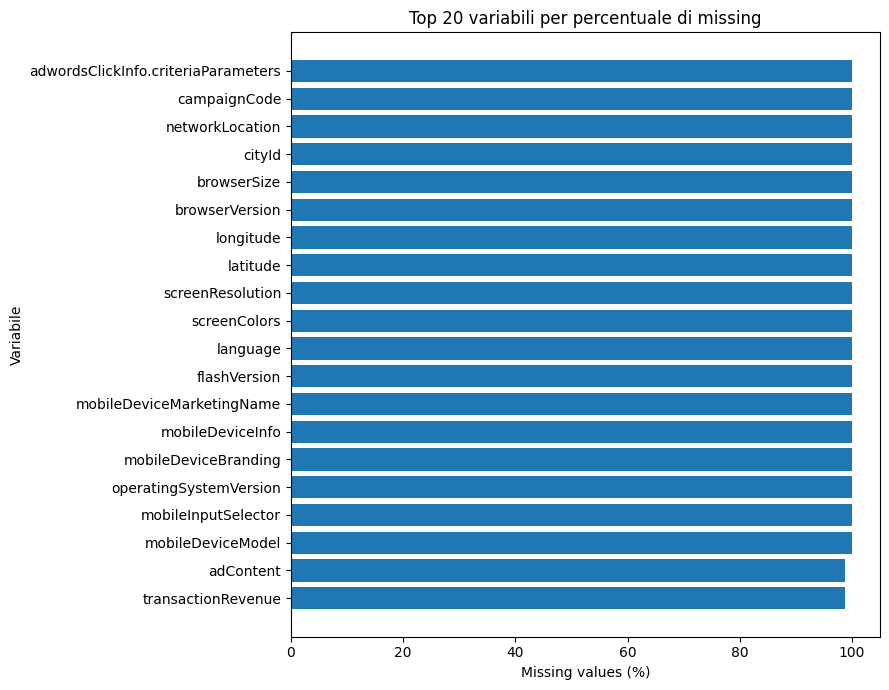

In [4]:

top_missing = missing_pct.head(20).sort_values()

plt.figure(figsize=(9, 7))
plt.barh(top_missing.index, top_missing.values)
plt.xlabel("Missing values (%)")
plt.ylabel("Variabile")
plt.title("Top 20 variabili per percentuale di missing")
plt.tight_layout()
plt.show()



### Interpretazione

Il dataset contiene numerose colonne completamente o quasi completamente prive di informazione. Nel codice R originale queste variabili venivano eliminate; manteniamo la stessa logica.

Un miglioramento importante è evitare la conversione indiscriminata di **tutte** le colonne a testo: in Python modifichiamo soltanto le colonne testuali, preservando per quanto possibile i tipi numerici.



## 4. Cleaning — replica corretta della logica originale

Durante la revisione degli script R sono emersi alcuni punti da correggere:

1. la maschera usata per identificare i `country` sconosciuti faceva riferimento a `subContinent`;
2. `Windows Phone` non veniva realmente accorpato a `Altri OS`;
3. l'ora veniva ricostruita con `cut(0:24)`, generando un problema per le sessioni delle 00:00;
4. diversi browser rari potevano rimanere fuori dalle categorie previste;
5. `transactionRevenue` veniva usata sia come ricavo sia come target: qui manteniamo il ricavo e creiamo una nuova colonna `purchase`.


In [5]:

def clean_gstore(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1) Placeholder testuale -> NA, solo sulle colonne testuali
    object_cols = df.select_dtypes(include=["object", "string"]).columns
    for col in object_cols:
        s = df[col].astype("string")
        df[col] = s.mask(s.eq("not available in demo dataset"))

    # 2) Elimina colonne completamente vuote
    df = df.dropna(axis=1, how="all")

    # 3) Ricavi: NA significa nessun acquisto
    df["transactionRevenue"] = (
        pd.to_numeric(df["transactionRevenue"], errors="coerce")
          .fillna(0)
    )

    # 4) Variabili escluse anche nel lavoro originale
    drop_cols = [
        "adwordsClickInfo.gclId",
        "adwordsClickInfo.slot",
        "adwordsClickInfo.page",
        "adwordsClickInfo.adNetworkType",
        "adwordsClickInfo.isVideoAd",
        "adContent",
        "keyword",
        "referralPath",
        "networkDomain",
        "campaign",
        "socialEngagementType",
        "city",
        "metro",
        "region",
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # 5) Indicatori / conteggi con missing interpretabili
    for col, fill_value in [
        ("newVisits", 0),
        ("bounces", 0),
        ("pageviews", 1),
    ]:
        if col in df.columns:
            df[col] = (
                pd.to_numeric(df[col], errors="coerce")
                  .fillna(fill_value)
            )

    if "isTrueDirect" in df.columns:
        df["isTrueDirect"] = (
            df["isTrueDirect"]
              .astype("object")
              .where(df["isTrueDirect"].notna(), False)
        )

    # 6) Raggruppamento della sorgente
    source = df["source"].astype("string")
    df["source"] = np.select(
        [
            source.str.contains("google", case=False, na=False),
            source.str.contains("youtube", case=False, na=False),
            source.str.contains("direct", case=False, na=False),
        ],
        ["Google", "Youtube", "Direct"],
        default="Altri",
    )

    # 7) Valori geografici '(not set)' -> Sconosciuto
    # Correzione rispetto allo script R: country usa la propria colonna.
    for col in ["continent", "subContinent", "country"]:
        mask = (
            df[col]
              .astype("string")
              .str.contains("not set", case=False, na=False)
        )
        df.loc[mask, col] = "Sconosciuto"

    # 8) Sistemi operativi principali
    os_keep = ["Android", "Chrome OS", "iOS", "Linux", "Macintosh", "Windows"]
    df["operatingSystem"] = df["operatingSystem"].where(
        df["operatingSystem"].isin(os_keep),
        "Altri OS",
    )

    # 9) Browser principali
    browser_keep = ["Chrome", "Edge", "Firefox", "Internet Explorer", "Safari"]
    df["browser"] = df["browser"].where(
        df["browser"].isin(browser_keep),
        "Altri",
    )

    # 10) Medium
    if "medium" in df.columns:
        df["medium"] = df["medium"].replace("(not set)", "Sconosciuto")

    # 11) Tipi
    df["date"] = pd.to_datetime(
        df["date"].astype(str),
        format="%Y%m%d",
        errors="coerce",
    )
    df["visitStartTime"] = pd.to_datetime(
        pd.to_numeric(df["visitStartTime"], errors="coerce"),
        unit="s",
        utc=True,
    )

    for col in [
        "visitNumber",
        "visits",
        "hits",
        "pageviews",
        "newVisits",
        "bounces",
        "transactionRevenue",
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 12) Altre ricodifiche
    df["channelGrouping"] = df["channelGrouping"].replace("(Other)", "Altri")

    rare_subcontinents = [
        "Caribbean",
        "Central Asia",
        "Eastern Africa",
        "Melanesia",
        "Micronesian Region",
        "Middle Africa",
        "Northern Africa",
        "Polynesia",
        "Southern Africa",
        "Western Africa",
        "Unknown",
        "Sconosciuto",
    ]
    df.loc[
        df["subContinent"].isin(rare_subcontinents),
        "subContinent"
    ] = "Altri"

    # 13) Feature temporali
    # Replica la numerazione lubridate originale: Sunday=1, Monday=2, ...
    df["dow"] = ((df["visitStartTime"].dt.dayofweek + 1) % 7) + 1
    df["weekday"] = df["visitStartTime"].dt.day_name()

    # Correzione del vecchio cut(0:24): ora direttamente 0..23
    df["hours"] = df["visitStartTime"].dt.hour
    df["month"] = df["date"].dt.month

    # 14) Ricavo in dollari e logaritmo come nel lavoro originale
    df["revenue_usd"] = df["transactionRevenue"] / 1_000_000
    df["log_revenue"] = np.log1p(df["transactionRevenue"])

    # 15) Target binaria separata dal ricavo
    df["purchase"] = (df["transactionRevenue"] > 0).astype("int8")
    df["newVisits"] = df["newVisits"].fillna(0).astype("int8")

    # 16) Identificativi e variabili non usate nella modellazione originale
    final_drop = [
        "Unnamed: 0",
        "X1",
        "fullVisitorId",
        "sessionId",
        "visitId",
        "isMobile",
        "visits",
        "isTrueDirect",
        "deviceCategory",
        "bounces",
        "medium",
    ]
    df = df.drop(columns=[c for c in final_drop if c in df.columns])

    return df


df = clean_gstore(raw)

print(f"Shape dopo il cleaning: {df.shape}")
display(df.head())


Shape dopo il cleaning: (25000, 21)


,channelGrouping,date,visitNumber,visitStartTime,browser,operatingSystem,continent,subContinent,country,hits,pageviews,newVisits,transactionRevenue,source,dow,weekday,hours,month,revenue_usd,log_revenue,purchase
0,Social,2017-02-28,1,2017-02-28 19:29:51+00:00,Chrome,Windows,Americas,Central America,Mexico,1,1.00,1,0.00,Youtube,3,Tuesday,19,2,0.00,0.00,0
1,Social,2016-10-21,1,2016-10-21 11:31:32+00:00,Chrome,Windows,Europe,Northern Europe,Norway,1,1.00,1,0.00,Youtube,6,Friday,11,10,0.00,0.00,0
2,Organic Search,2017-02-13,1,2017-02-13 18:41:36+00:00,Safari,Macintosh,Americas,South America,Brazil,9,9.00,1,0.00,Google,2,Monday,18,2,0.00,0.00,0
3,Direct,2017-03-22,8,2017-03-22 16:49:30+00:00,Chrome,Chrome OS,Europe,Western Europe,France,1,1.00,0,0.00,Direct,4,Wednesday,16,3,0.00,0.00,0
4,Organic Search,2017-01-02,1,2017-01-02 08:06:50+00:00,Chrome,Windows,Asia,Southeast Asia,Philippines,2,2.00,1,0.00,Google,2,Monday,8,1,0.00,0.00,0


In [6]:

cleaning_summary = pd.DataFrame(
    {
        "Metrica": [
            "Osservazioni",
            "Variabili prima del cleaning",
            "Variabili dopo il cleaning",
            "Sessioni con acquisto",
            "Sessioni senza acquisto",
            "Purchase rate",
            "Ora minima",
            "Ora massima",
        ],
        "Valore": [
            len(df),
            raw.shape[1],
            df.shape[1],
            int(df["purchase"].sum()),
            int((df["purchase"] == 0).sum()),
            f'{df["purchase"].mean() * 100:.2f}%',
            int(df["hours"].min()),
            int(df["hours"].max()),
        ],
    }
)

display(cleaning_summary)


,Metrica,Valore
0,Osservazioni,25000
1,Variabili prima del cleaning,56
2,Variabili dopo il cleaning,21
3,Sessioni con acquisto,323
4,Sessioni senza acquisto,24677
5,Purchase rate,1.29%
6,Ora minima,0
7,Ora massima,23



### Risultato del cleaning

Il campione rimane composto da **25.000 sessioni**. La target binaria conferma il forte sbilanciamento già evidenziato nella tesi: circa **1,3% di acquisti**.

La nuova variabile `hours` copre correttamente l'intervallo **0–23**. Questo elimina il problema del vecchio binning R, nel quale le osservazioni a mezzanotte potevano diventare `NA`.


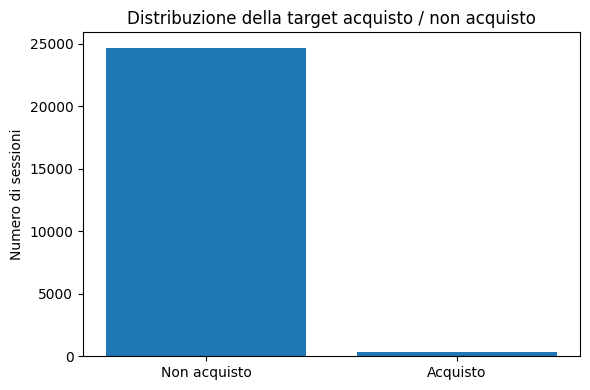

Acquisti: 323 / 25,000 (1.29%)


In [7]:

target_counts = df["purchase"].value_counts().sort_index()
target_labels = ["Non acquisto", "Acquisto"]

plt.figure(figsize=(6, 4))
plt.bar(target_labels, target_counts.values)
plt.ylabel("Numero di sessioni")
plt.title("Distribuzione della target acquisto / non acquisto")
plt.tight_layout()
plt.show()

print(
    f"Acquisti: {int(df['purchase'].sum()):,} / {len(df):,} "
    f"({df['purchase'].mean() * 100:.2f}%)"
)



### Interpretazione

L'accuracy da sola non sarà una metrica adeguata: un classificatore che prevedesse sempre **“non acquisto”** avrebbe già un'accuracy vicina al 99%.

Nella Parte 2 useremo quindi metriche come **recall/sensitivity, precision, F1, ROC-AUC e PR-AUC**.



## 5. Split temporale usato per l'EDA

Lo script R ordinava le sessioni per `visitStartTime` e utilizzava le prime **20.000 osservazioni (80%)** come training set.

Manteniamo questo comportamento per ricostruire il più fedelmente possibile l'EDA della tesi.


In [8]:

df_sorted = df.sort_values("visitStartTime").reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.80)
train_eda = df_sorted.iloc[:split_idx].copy()
test_holdout = df_sorted.iloc[split_idx:].copy()

split_summary = pd.DataFrame(
    {
        "Dataset": ["Train / EDA", "Holdout"],
        "N": [len(train_eda), len(test_holdout)],
        "Data iniziale": [
            train_eda["date"].min().date(),
            test_holdout["date"].min().date(),
        ],
        "Data finale": [
            train_eda["date"].max().date(),
            test_holdout["date"].max().date(),
        ],
        "Purchase rate": [
            train_eda["purchase"].mean(),
            test_holdout["purchase"].mean(),
        ],
    }
)

display(split_summary)


,Dataset,N,Data iniziale,Data finale,Purchase rate
0,Train / EDA,20000,2016-08-01,2017-05-08,0.01
1,Holdout,5000,2017-05-08,2017-08-01,0.02



## 6. Distribuzione dei ricavi

Nel codice R originale i ricavi venivano ordinati e visualizzati in scala logaritmica. Replichiamo prima quel punto di vista e poi aggiungiamo un istogramma, più adatto a descrivere una distribuzione.


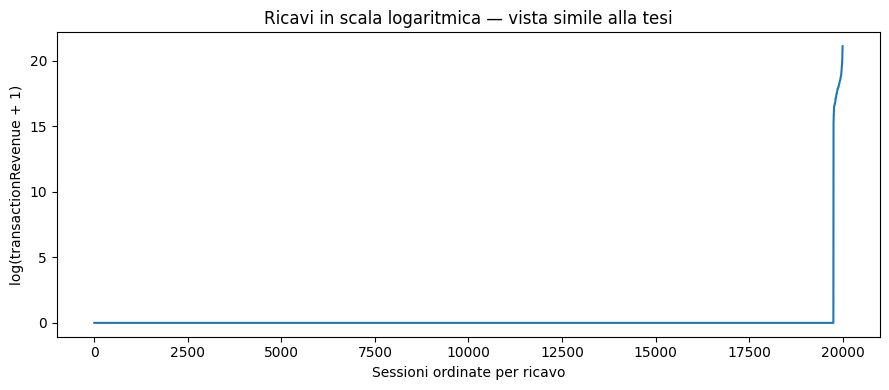

In [9]:

ordered_log_revenue = train_eda["log_revenue"].sort_values().reset_index(drop=True)

plt.figure(figsize=(9, 4))
plt.plot(ordered_log_revenue.values)
plt.xlabel("Sessioni ordinate per ricavo")
plt.ylabel("log(transactionRevenue + 1)")
plt.title("Ricavi in scala logaritmica — vista simile alla tesi")
plt.tight_layout()
plt.show()


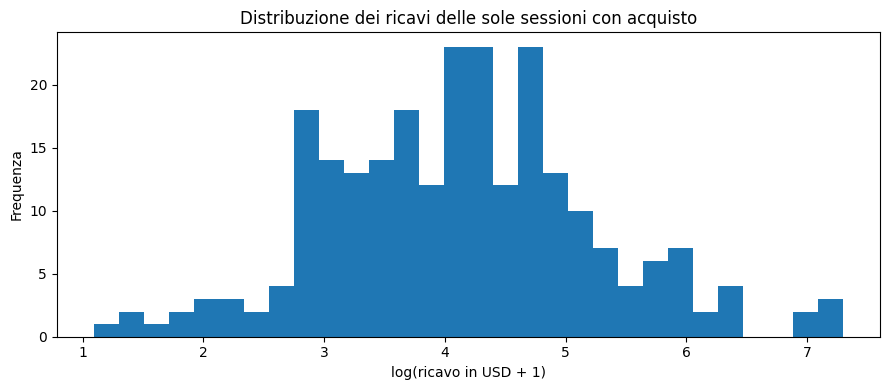

,Revenue USD
count,246.00
mean,119.35
std,201.66
min,1.99
25%,27.25
50%,60.78
75%,119.78
max,"1,473.35"


In [10]:

positive_revenue = train_eda.loc[
    train_eda["purchase"].eq(1),
    "revenue_usd"
]

plt.figure(figsize=(9, 4))
plt.hist(np.log1p(positive_revenue), bins=30)
plt.xlabel("log(ricavo in USD + 1)")
plt.ylabel("Frequenza")
plt.title("Distribuzione dei ricavi delle sole sessioni con acquisto")
plt.tight_layout()
plt.show()

display(positive_revenue.describe().to_frame("Revenue USD"))



### Interpretazione

La distribuzione dei ricavi è fortemente asimmetrica: la trasformazione logaritmica riduce l'effetto delle transazioni di importo molto elevato.

Separare le sole sessioni con acquisto evita che la massa di zeri domini completamente il grafico.



## 7. Browser


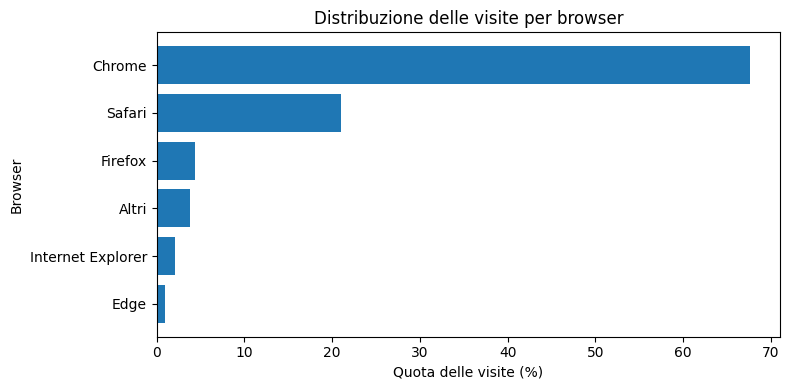

,Visite %
browser,
Chrome,67.66
Safari,21.02
Firefox,4.41
Altri,3.85
Internet Explorer,2.06
Edge,1.00


In [11]:

browser_share = (
    train_eda["browser"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8, 4))
plt.barh(browser_share.index, browser_share.values)
plt.xlabel("Quota delle visite (%)")
plt.ylabel("Browser")
plt.title("Distribuzione delle visite per browser")
plt.tight_layout()
plt.show()

display(browser_share.sort_values(ascending=False).to_frame("Visite %"))



### Interpretazione

Chrome domina nettamente il traffico del training set, seguito da Safari. La ricodifica delle categorie rare evita il problema presente nel vecchio script, dove alcune etichette della torta potevano non corrispondere all'ordine reale dei livelli.


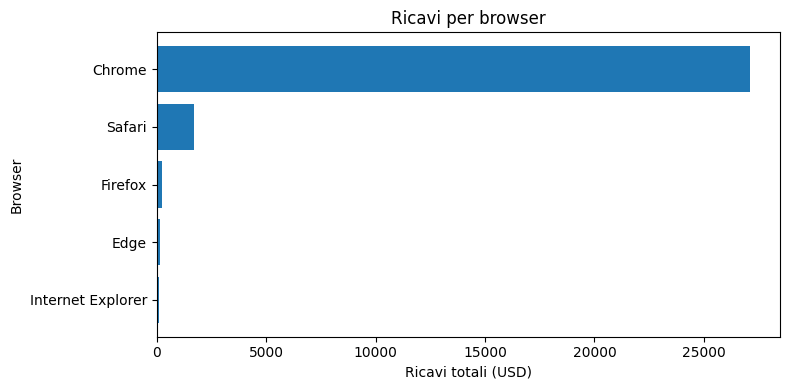

,Revenue USD
browser,
Chrome,"27,123.71"
Safari,"1,714.45"
Firefox,237.87
Edge,160.68
Internet Explorer,123.25


In [12]:

browser_revenue = (
    train_eda.loc[train_eda["purchase"].eq(1)]
    .groupby("browser", observed=True)["revenue_usd"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(8, 4))
plt.barh(browser_revenue.index, browser_revenue.values)
plt.xlabel("Ricavi totali (USD)")
plt.ylabel("Browser")
plt.title("Ricavi per browser")
plt.tight_layout()
plt.show()

display(browser_revenue.sort_values(ascending=False).to_frame("Revenue USD"))



## 8. Channel grouping


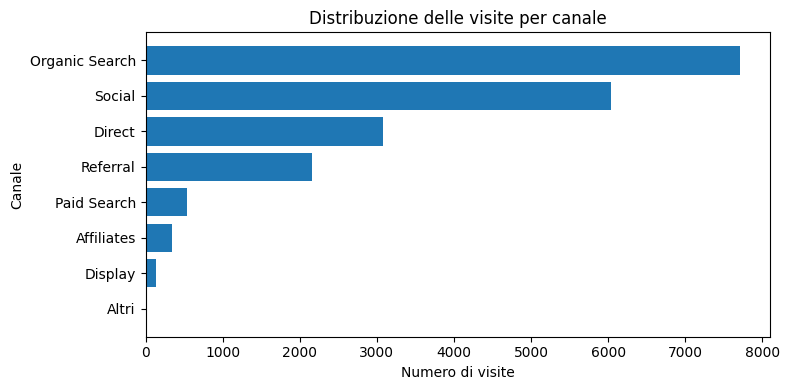

In [13]:

channel_visits = train_eda["channelGrouping"].value_counts().sort_values()

plt.figure(figsize=(8, 4))
plt.barh(channel_visits.index, channel_visits.values)
plt.xlabel("Numero di visite")
plt.ylabel("Canale")
plt.title("Distribuzione delle visite per canale")
plt.tight_layout()
plt.show()


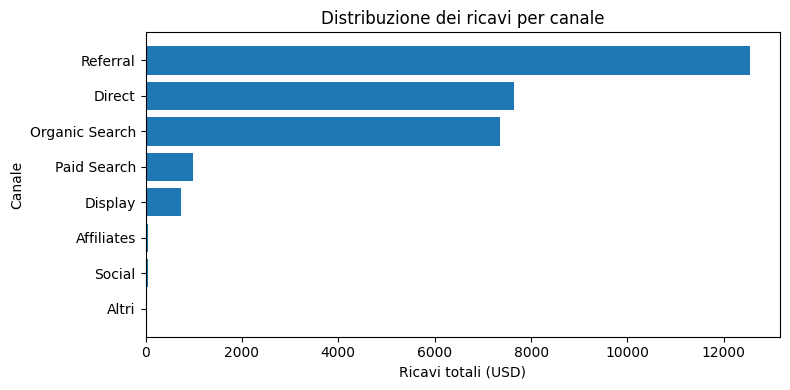

,Revenue USD
channelGrouping,
Referral,"12,537.87"
Direct,"7,643.34"
Organic Search,"7,352.03"
Paid Search,980.83
Display,743.17
Affiliates,53.75
Social,48.97
Altri,0.00


In [14]:

channel_revenue = (
    train_eda.groupby("channelGrouping", observed=True)["revenue_usd"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(8, 4))
plt.barh(channel_revenue.index, channel_revenue.values)
plt.xlabel("Ricavi totali (USD)")
plt.ylabel("Canale")
plt.title("Distribuzione dei ricavi per canale")
plt.tight_layout()
plt.show()

display(channel_revenue.sort_values(ascending=False).to_frame("Revenue USD"))



### Interpretazione

Il canale con più visite non coincide necessariamente con quello che genera più ricavi. Questo è un esempio utile di come una metrica di volume e una metrica di valore possano raccontare storie diverse.



## 9. Sistemi operativi


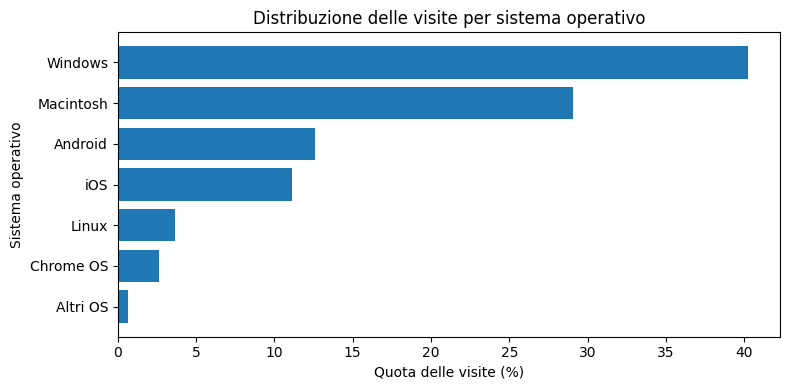

,Visite %
operatingSystem,
Windows,40.27
Macintosh,29.05
Android,12.62
iOS,11.12
Linux,3.65
Chrome OS,2.61
Altri OS,0.66


In [15]:

os_share = (
    train_eda["operatingSystem"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8, 4))
plt.barh(os_share.index, os_share.values)
plt.xlabel("Quota delle visite (%)")
plt.ylabel("Sistema operativo")
plt.title("Distribuzione delle visite per sistema operativo")
plt.tight_layout()
plt.show()

display(os_share.sort_values(ascending=False).to_frame("Visite %"))


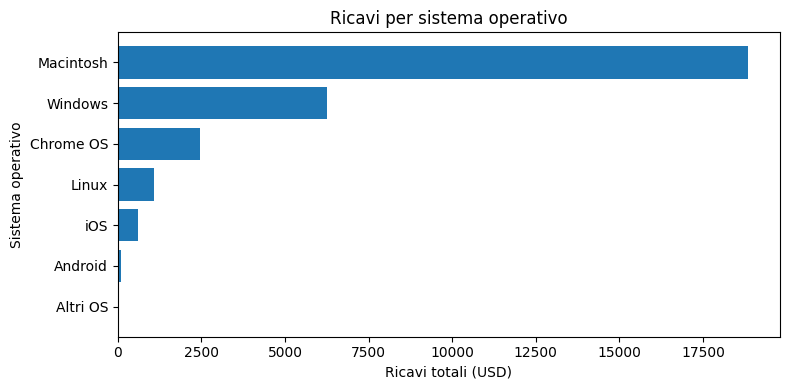

In [16]:

os_revenue = (
    train_eda.groupby("operatingSystem", observed=True)["revenue_usd"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(8, 4))
plt.barh(os_revenue.index, os_revenue.values)
plt.xlabel("Ricavi totali (USD)")
plt.ylabel("Sistema operativo")
plt.title("Ricavi per sistema operativo")
plt.tight_layout()
plt.show()



### Interpretazione

Windows è il sistema operativo più frequente, ma Macintosh genera nel campione una quota di ricavi molto elevata. Il dato suggerisce che la sola frequenza di utilizzo non è sufficiente per descrivere il valore economico del traffico.



## 10. Distribuzione geografica


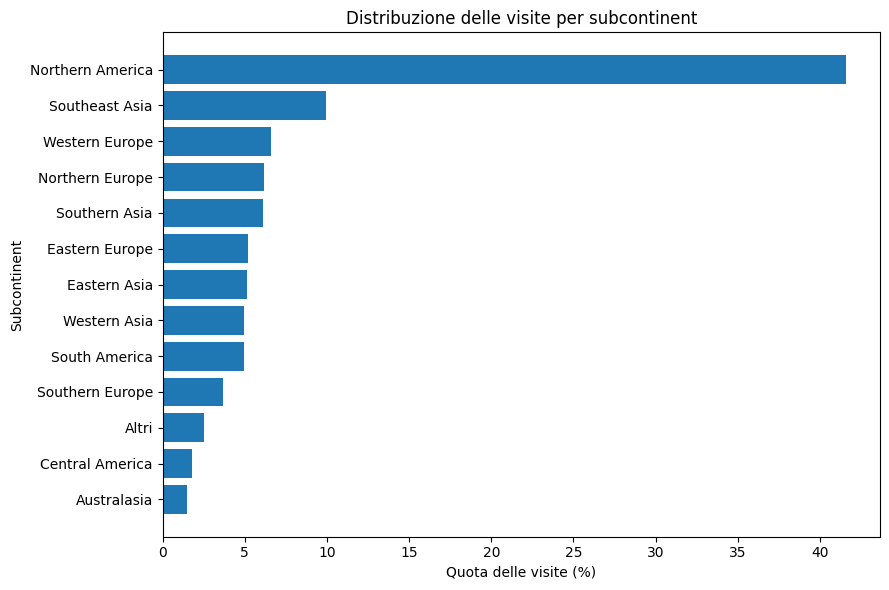

In [17]:

subcontinent_share = (
    train_eda["subContinent"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 6))
plt.barh(subcontinent_share.index, subcontinent_share.values)
plt.xlabel("Quota delle visite (%)")
plt.ylabel("Subcontinent")
plt.title("Distribuzione delle visite per subcontinent")
plt.tight_layout()
plt.show()


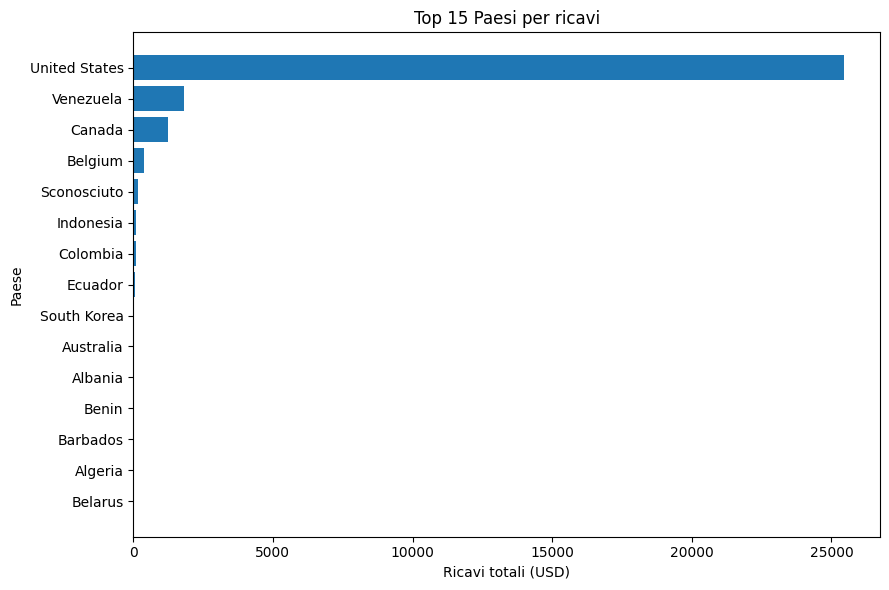

,Revenue USD
country,
United States,"25,466.76"
Venezuela,"1,812.10"
Canada,"1,260.37"
Belgium,374.00
Sconosciuto,173.30
Indonesia,101.94
Colombia,83.77
Ecuador,56.97
South Korea,30.75


In [18]:

country_revenue = (
    train_eda.groupby("country", observed=True)["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)

top_country_revenue = country_revenue.head(15).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_country_revenue.index, top_country_revenue.values)
plt.xlabel("Ricavi totali (USD)")
plt.ylabel("Paese")
plt.title("Top 15 Paesi per ricavi")
plt.tight_layout()
plt.show()

display(country_revenue.head(15).to_frame("Revenue USD"))



### Nota sulla mappa mondiale originale

La tesi utilizzava una world map costruita tramite il package `maps` di R. Nel progetto finale possiamo aggiungere una **mappa interattiva Plotly**; in questa prima baseline manteniamo una visualizzazione deterministica e completamente offline dei Paesi con maggior ricavo.

L'evidenza principale è comunque molto netta: gli **Stati Uniti** concentrano la grande maggioranza dei ricavi del campione.



## 11. Andamento temporale

Nel vecchio script le visite giornaliere e la somma dei log-ricavi venivano sovrapposte sullo stesso grafico e indicate come “distribuzione mensile”.

Qui le separiamo: le due grandezze hanno scale e significati diversi.


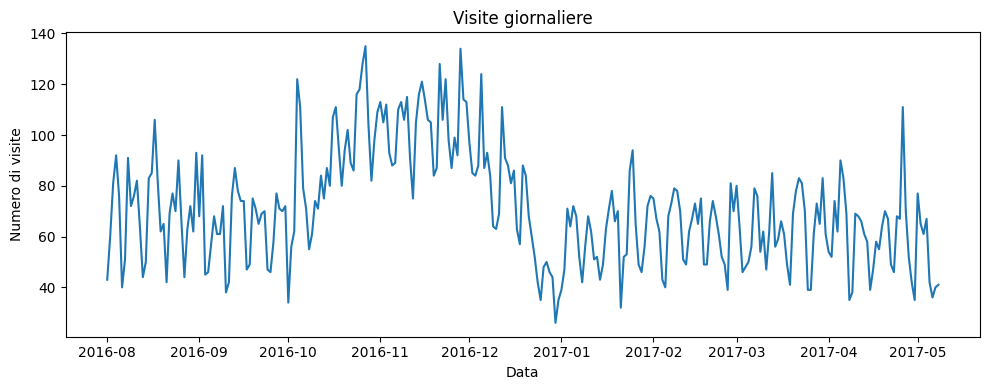

In [19]:

daily_visits = train_eda.groupby("date").size()

plt.figure(figsize=(10, 4))
plt.plot(daily_visits.index, daily_visits.values)
plt.xlabel("Data")
plt.ylabel("Numero di visite")
plt.title("Visite giornaliere")
plt.tight_layout()
plt.show()


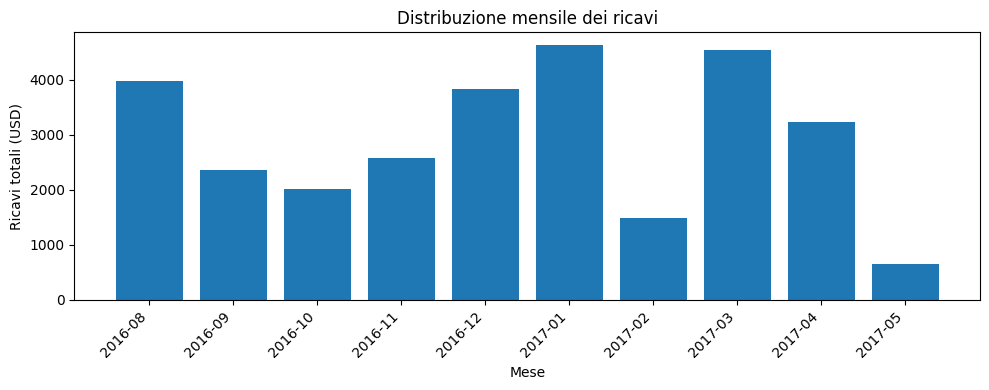

,Revenue USD
month_period,
2017-01,"4,634.87"
2017-03,"4,545.69"
2016-08,"3,986.15"
2016-12,"3,839.72"
2017-04,"3,232.07"
2016-11,"2,585.40"
2016-09,"2,370.24"
2016-10,"2,011.31"
2017-02,"1,498.67"


In [20]:

monthly_revenue = (
    train_eda
    .assign(month_period=train_eda["date"].dt.to_period("M"))
    .groupby("month_period")["revenue_usd"]
    .sum()
)

plt.figure(figsize=(10, 4))
plt.bar(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Mese")
plt.ylabel("Ricavi totali (USD)")
plt.title("Distribuzione mensile dei ricavi")
plt.tight_layout()
plt.show()

display(monthly_revenue.sort_values(ascending=False).to_frame("Revenue USD"))



### Interpretazione

La revisione separa correttamente **frequenza delle visite** e **valore economico delle transazioni**. Questo rende il grafico più leggibile e riduce il rischio di confrontare direttamente grandezze non omogenee.



## 12. Giorno della settimana × ora del giorno

Nello script R l'ora veniva ricostruita attraverso intervalli `cut(0:24)`. In Python utilizziamo direttamente l'ora del timestamp (`0–23`).

Le heatmap seguenti mostrano:

1. volume delle visite;
2. somma del log-ricavo.


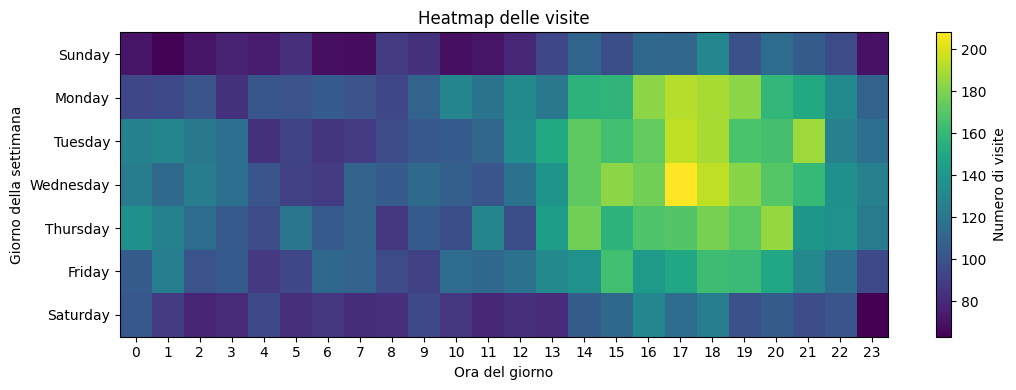

In [21]:

weekday_order = [
    "Sunday", "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday"
]

visits_heatmap = (
    train_eda
    .pivot_table(
        index="weekday",
        columns="hours",
        values="purchase",
        aggfunc="size",
        fill_value=0,
    )
    .reindex(weekday_order)
)

plt.figure(figsize=(11, 4))
plt.imshow(visits_heatmap.values, aspect="auto")
plt.xticks(range(24), range(24))
plt.yticks(range(len(weekday_order)), weekday_order)
plt.xlabel("Ora del giorno")
plt.ylabel("Giorno della settimana")
plt.title("Heatmap delle visite")
plt.colorbar(label="Numero di visite")
plt.tight_layout()
plt.show()


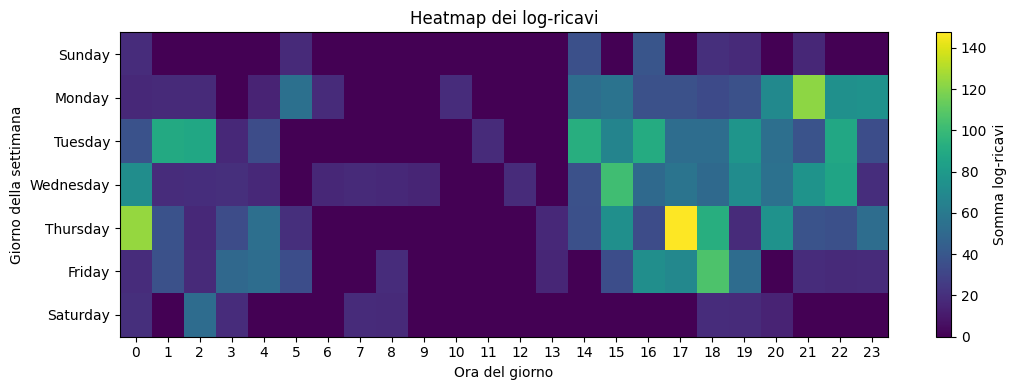

In [22]:

revenue_heatmap = (
    train_eda
    .pivot_table(
        index="weekday",
        columns="hours",
        values="log_revenue",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(weekday_order)
)

plt.figure(figsize=(11, 4))
plt.imshow(revenue_heatmap.values, aspect="auto")
plt.xticks(range(24), range(24))
plt.yticks(range(len(weekday_order)), weekday_order)
plt.xlabel("Ora del giorno")
plt.ylabel("Giorno della settimana")
plt.title("Heatmap dei log-ricavi")
plt.colorbar(label="Somma log-ricavi")
plt.tight_layout()
plt.show()



### Interpretazione

La heatmap è particolarmente utile perché combina due dimensioni temporali in una singola vista. Nel progetto finale potrà essere uno dei grafici più efficaci anche per comunicare i risultati a stakeholder non tecnici.



## 13. Pageviews


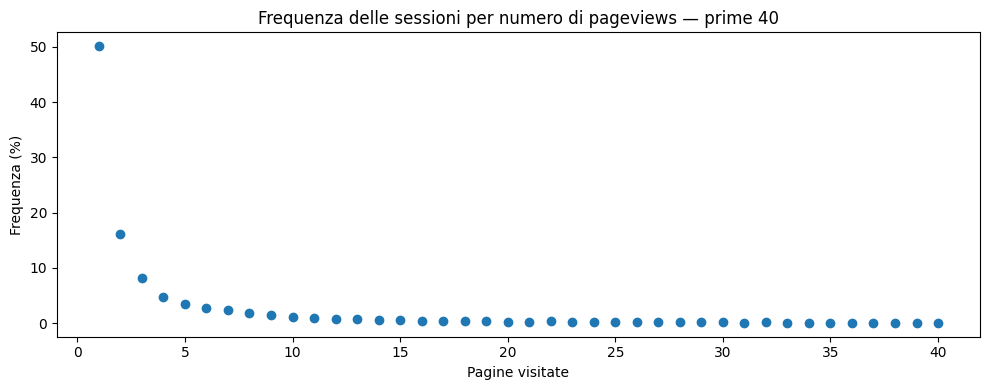

In [23]:

pageview_freq = (
    train_eda["pageviews"]
    .value_counts(normalize=True)
    .sort_index()
    .head(40)
    .mul(100)
)

plt.figure(figsize=(10, 4))
plt.scatter(pageview_freq.index, pageview_freq.values)
plt.xlabel("Pagine visitate")
plt.ylabel("Frequenza (%)")
plt.title("Frequenza delle sessioni per numero di pageviews — prime 40")
plt.tight_layout()
plt.show()


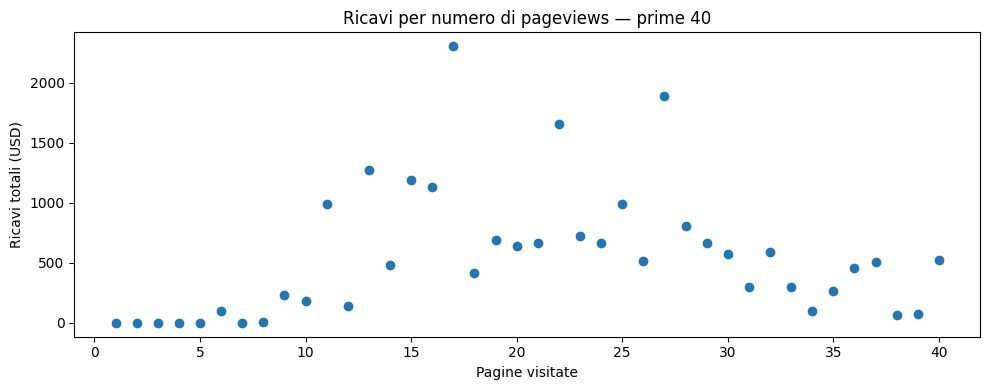

In [24]:

pageview_revenue = (
    train_eda
    .groupby("pageviews")["revenue_usd"]
    .sum()
    .sort_index()
    .head(40)
)

plt.figure(figsize=(10, 4))
plt.scatter(pageview_revenue.index, pageview_revenue.values)
plt.xlabel("Pagine visitate")
plt.ylabel("Ricavi totali (USD)")
plt.title("Ricavi per numero di pageviews — prime 40")
plt.tight_layout()
plt.show()


In [25]:

pageview_by_target = (
    train_eda
    .groupby("purchase")["pageviews"]
    .describe()[["count", "mean", "50%", "75%", "max"]]
)

display(pageview_by_target)


,count,mean,50%,75%,max
purchase,,,,,
0,"19,754.00",3.58,1.00,3.00,195.00
1,246.00,28.16,23.00,33.00,149.00



### Evidenza da approfondire nella Parte 2

Le sessioni che terminano con un acquisto presentano, in media, molte più `pageviews` rispetto alle sessioni senza acquisto.

Questo è importante, ma apre anche una domanda metodologica:

> se vogliamo **prevedere l'acquisto prima che la sessione sia terminata**, possiamo davvero utilizzare il numero finale di pageviews e hits?

Per questo motivo nella revisione 2026 confronteremo i modelli **con e senza `hits` e `pageviews`**.



## 14. Check finale della Parte 1


In [26]:

checks = pd.Series(
    {
        "25.000 osservazioni preservate": len(df) == 25_000,
        "Nessun missing nella target": df["purchase"].isna().sum() == 0,
        "Target binaria 0/1": set(df["purchase"].unique()) <= {0, 1},
        "Ore comprese tra 0 e 23": df["hours"].between(0, 23).all(),
        "Ricavo e target mantenuti separati": (
            "transactionRevenue" in df.columns
            and "purchase" in df.columns
        ),
        "Split EDA da 20.000 osservazioni": len(train_eda) == 20_000,
    }
)

display(checks.to_frame("OK"))
assert checks.all(), "Uno o più controlli della pipeline non sono superati."


,OK
25.000 osservazioni preservate,True
Nessun missing nella target,True
Target binaria 0/1,True
Ore comprese tra 0 e 23,True
Ricavo e target mantenuti separati,True
Split EDA da 20.000 osservazioni,True



# Conclusioni della Parte 1

La ricostruzione Python conferma i punti centrali dell'analisi originale:

- il campione contiene **25.000 sessioni**;
- la classe positiva rappresenta circa **1,3%** delle osservazioni;
- il dataset richiede una gestione attenta dei valori mancanti e delle categorie rare;
- browser, sistemi operativi, canali e geografia presentano distribuzioni molto concentrate;
- i ricavi sono fortemente asimmetrici;
- `pageviews` e `hits` sembrano fortemente associati all'acquisto e dovranno essere analizzati con attenzione per evitare un obiettivo predittivo poco realistico.

## Next step — Parte 2

La fase successiva ricostruirà e confronterà:

- Logistic Regression
- Linear Discriminant Analysis
- Support Vector Machine
- dataset originale vs numerico
- SMOTE / ROSE / MWMOTE (o equivalente riproducibile in Python)

Successivamente verrà creata una pipeline **2026** più rigorosa con:

- preprocessing fit solo sul training set;
- cross-validation;
- resampling all'interno dei fold;
- hyperparameter tuning;
- ROC-AUC e PR-AUC;
- threshold analysis;
- confronto con/senza `hits` e `pageviews`.

L'obiettivo finale non è dimostrare che Python sia “migliore” di R, ma capire **cosa cambierebbe oggi nell'approccio metodologico**.
